# Importing Libraries

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf
from tensorflow.keras import layers, models, backend as K
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau

# Custom Correlation Regularizer Class


In [2]:
class CorrelationRegularizer(tf.keras.regularizers.Regularizer):
  def __init__(self, weight=1e-3):
    self.weight = weight

  def __call__(self, x):
    w_norm = x / (K.sqrt(K.sum(K.square(x), axis=0, keepdims=True)) + K.epsilon())
    corr_matrix = K.dot(K.transpose(w_norm), w_norm)
    identity = tf.eye(K.int_shape(corr_matrix)[0])
    off_diag = corr_matrix - identity
    return self.weight * K.sum(K.square(off_diag))

  def get_config(self):
    return {'weight': self.weight}

# Load Augmented and Standardized Data

In [4]:
df = pd.read_hdf('iemocap_features_augmented.h5', key='df')

#features 'feat_1 to feat_240'
feature_columns = [f"feat_{i}" for i in range(1, 241)]
X = df[feature_columns].values
X = X.reshape(-1, 40, 6, 1)
#print(np.isnan(X).sum(), np.isinf(X).sum())

# Processing Labels
y_raw = df['emotion'].str.lower().values
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_raw)
y = to_categorical(y_encoded, num_classes=4)



# Splitting Data
X_train, X_val, y_train, y_val = train_test_split(X, y,test_size=0.2, random_state=42, stratify=y)


# Building Model

In [5]:
def build_model(input_shape=(40, 6, 1)):
  inputs = layers.Input(shape=input_shape)

  # First Convolution Block
  x = layers.Conv2D(32, (3,3), padding='same', activation='relu')(inputs)
  x = layers.BatchNormalization()(x)
  x = layers.MaxPooling2D(2,2)(x)
  x = layers.Dropout(0.3)(x)

  # Second Convolutional Block
  x = layers.Conv2D(64, (3,3), padding='same', activation='relu')(x)
  x = layers.BatchNormalization()(x)
  x = layers.MaxPooling2D(2,2)(x)
  x = layers.Dropout(0.3)(x)

  # Third Convolutional Block
  x = layers.Conv2D(128, (3,3), padding='same', activation='relu')(x)
  x = layers.BatchNormalization()(x)
  x = layers.Dropout(0.3)(x)

  # Flattening the feature maps and adding Dense Layer
  x = layers.Flatten()(x)
  x = layers.Dense(128, activation='relu', kernel_regularizer=CorrelationRegularizer(weight=1e-3))(x)
  x = layers.Dropout(0.5)(x)
  outputs = layers.Dense(4, activation='softmax')(x)

  model = models.Model(inputs=inputs, outputs=outputs)
  return model


# Callbacks

In [6]:
model = build_model()
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

checkpoint = ModelCheckpoint('dcnn_ser_weights.keras', monitor='val_accuracy', verbose=1, save_best_only=True, mode='max')
lr_reducer = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, verbose=1)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 40, 6, 1)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 40, 6, 32)           │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 40, 6, 32)           │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 20, 3, 32)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 20, 3, 32)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 20, 3, 64)           │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 20, 3, 64)           │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 10, 1, 64)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 10, 1, 64)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 10, 1, 128)          │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 10, 1, 128)          │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 10, 1, 128)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 1280)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         163,968 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 4)                   │             516 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 258,052 (1008.02 KB)

 Trainable params: 257,604 (1006.27 KB)

 Non-trainable params: 448 (1.75 KB)

# Training The Model

In [7]:
history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=100, batch_size=32, callbacks=[checkpoint, lr_reducer])

# Save the final model (native Keras format)
model.save('final_dcnn_ser_model_improved.keras')
print("Model saved for real-time inference.")

# Evaluate the model on the validation set.
val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)
print(f"Validation Accuracy: {val_acc * 100:.2f}%")

Epoch 1/100
560/562 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.4822 - loss: 1.4457
Epoch 1: val_accuracy improved from -inf to 0.60668, saving model to dcnn_ser_weights.keras
562/562 ━━━━━━━━━━━━━━━━━━━━ 23s 33ms/step - accuracy: 0.4824 - loss: 1.4445 - val_accuracy: 0.6067 - val_loss: 0.9805 - learning_rate: 0.0010
Epoch 2/100
561/562 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.5797 - loss: 1.0332
Epoch 2: val_accuracy improved from 0.60668 to 0.63541, saving model to dcnn_ser_weights.keras
562/562 ━━━━━━━━━━━━━━━━━━━━ 19s 30ms/step - accuracy: 0.5797 - loss: 1.0332 - val_accuracy: 0.6354 - val_loss: 0.9171 - learning_rate: 0.0010
Epoch 3/100
561/562 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.5950 - loss: 0.9988
Epoch 3: val_accuracy improved from 0.63541 to 0.64566, saving model to dcnn_ser_weights.keras
562/562 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.5951 - loss: 0.9988 - val_accuracy: 0.6457 - val_loss: 0.8837 - learning_rate: 0.0010
Epoch 4/100
562/562 ━━━━━

# Visualizing training vs validation loss and accuracy

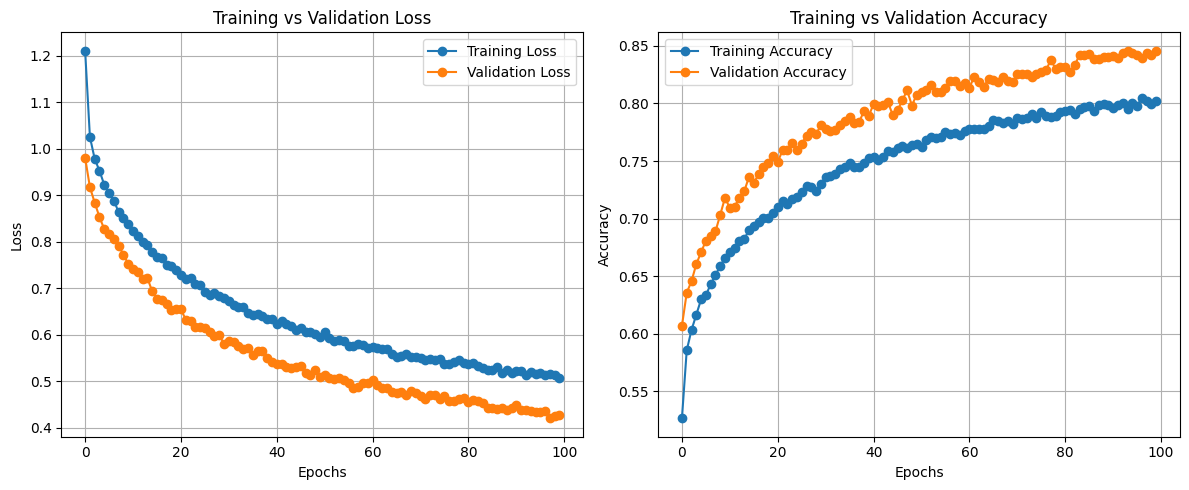

In [8]:
import matplotlib.pyplot as plt

# Plot Loss
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='o')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


# Saving Label Encoder

In [9]:
import joblib
joblib.dump(label_encoder, 'label_encoder.pkl')
print("Label encoder saved as 'label_encoder.pkl'")


Label encoder saved as 'label_encoder.pkl'
